In [1]:
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
fraud = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

fraud.head()

,user_id,purchase_value,age,ip_address,class,time_since_signup,hour_of_day,day_of_week,transaction_count,transactions_per_device,...,country_United States,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,247547,0.549607,-0.363124,16778864,0,-0.413800,3,6,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
1,220737,-1.197335,0.101168,16842045,0,-1.180852,20,2,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
2,390400,0.385831,-0.479197,16843656,0,-0.936126,23,5,0.0,0.112503,...,False,False,False,False,False,False,False,False,False,False
3,69592,0.986342,-0.363124,16938732,0,0.867086,16,5,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False
4,174987,0.767974,0.449387,16971984,0,1.700633,4,1,0.0,-0.264069,...,False,False,False,False,False,False,False,False,False,False


In [4]:
X = fraud.drop(
    columns=["class"]
)

y = fraud["class"]

In [5]:
bool_cols = X.select_dtypes(
    include=["bool"]
).columns

for col in bool_cols:
    X[col] = X[col].astype(int)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [8]:
feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,time_since_signup,0.481588
8,transactions_per_device,0.432978
3,ip_address,0.009487
2,age,0.007293
1,purchase_value,0.007242
5,hour_of_day,0.007184
9,lower_bound_ip_address,0.007041
10,upper_bound_ip_address,0.006904
6,day_of_week,0.006821
0,user_id,0.005538


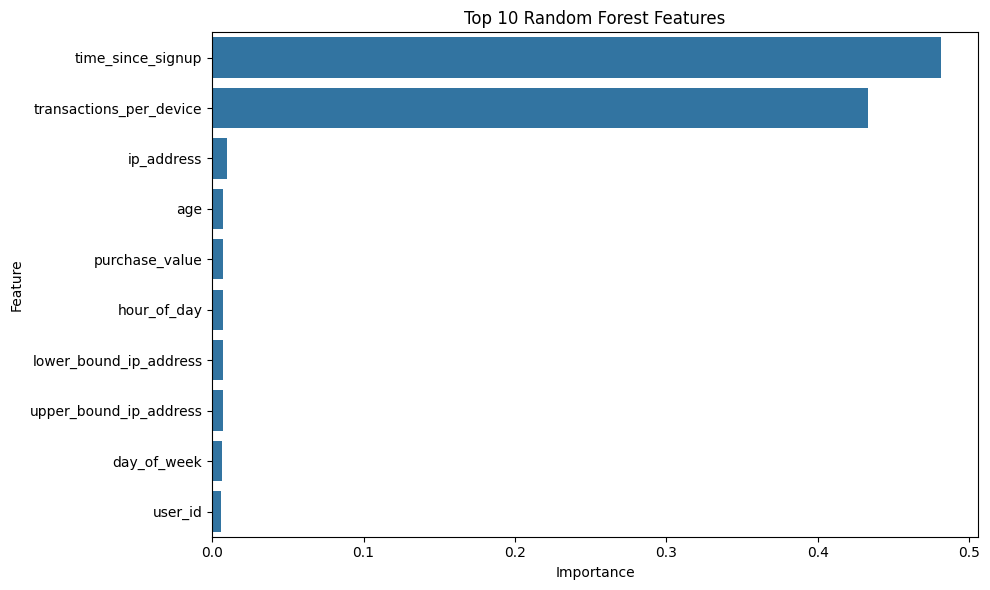

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.tight_layout()

plt.show()

In [10]:
explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

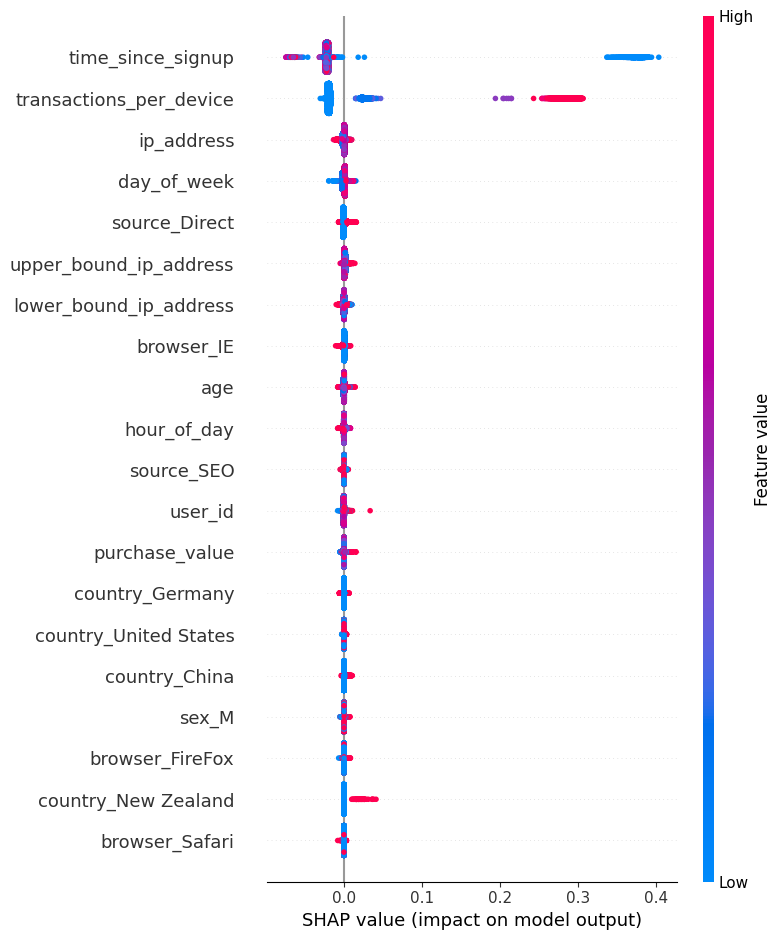

In [23]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [33]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[23376     0]
 [ 1116  1338]]


In [37]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred

tp_rows = results[
    (results["actual"] == 1) &
    (results["predicted"] == 1)
]

fp_rows = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

fn_rows = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("TP count:", len(tp_rows))
print("FP count:", len(fp_rows))
print("FN count:", len(fn_rows))

TP count: 1338
FP count: 0
FN count: 1116


In [36]:
print(confusion_matrix(y_test, y_pred))

print("\nPrediction counts:")
print(pd.Series(y_pred).value_counts())

[[23376     0]
 [ 1116  1338]]

Prediction counts:
0    24492
1     1338
Name: count, dtype: int64


In [39]:
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
[0.90498969 0.09501031]


In [32]:
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
[0.90498969 0.09501031]


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       1.00      0.55      0.71      2454

    accuracy                           0.96     25830
   macro avg       0.98      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830



In [22]:
print(X_test.shape)

(25830, 198)


In [12]:
y_pred = best_model.predict(
    X_test
)

results = X_test.copy()

results["actual"] = y_test.values

results["predicted"] = y_pred

In [13]:
tp_index = results[
    (results["actual"] == 1)
    &
    (results["predicted"] == 1)
].index[0]

tp_index

np.int64(118326)

In [29]:
fp_index = results[
    (results["actual"] == 0)
    &
    (results["predicted"] == 1)
].index[0]

fp_index

IndexError: index 0 is out of bounds for axis 0 with size 0

In [15]:
fn_index = results[
    (results["actual"] == 1)
    &
    (results["predicted"] == 0)
].index[0]

fn_index

np.int64(12320)

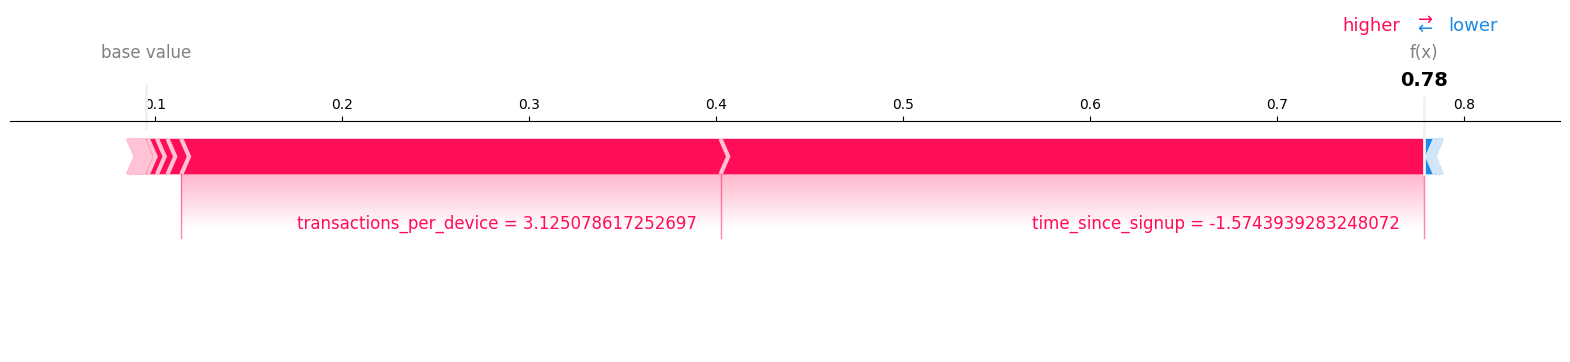

In [24]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[
        X_test.index.get_loc(tp_index),
        :,
        1
    ],
    X_test.loc[tp_index],
    matplotlib=True
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[
        X_test.index.get_loc(fp_index_30),
        :,
        1
    ],
    X_test.loc[fp_index_30],
    matplotlib=True
)

NameError: name 'fp_index' is not defined

In [41]:
y_prob = best_model.predict_proba(X_test)[:,1]

print(y_prob.min())
print(y_prob.max())

0.03530950085296849
0.863121431973952


In [42]:
print(type(explainer.expected_value))
print(explainer.expected_value)

y_prob = best_model.predict_proba(X_test)[:,1]
print(y_prob.min())
print(y_prob.max())

<class 'numpy.ndarray'>
[0.90498969 0.09501031]
0.03530950085296849
0.863121431973952


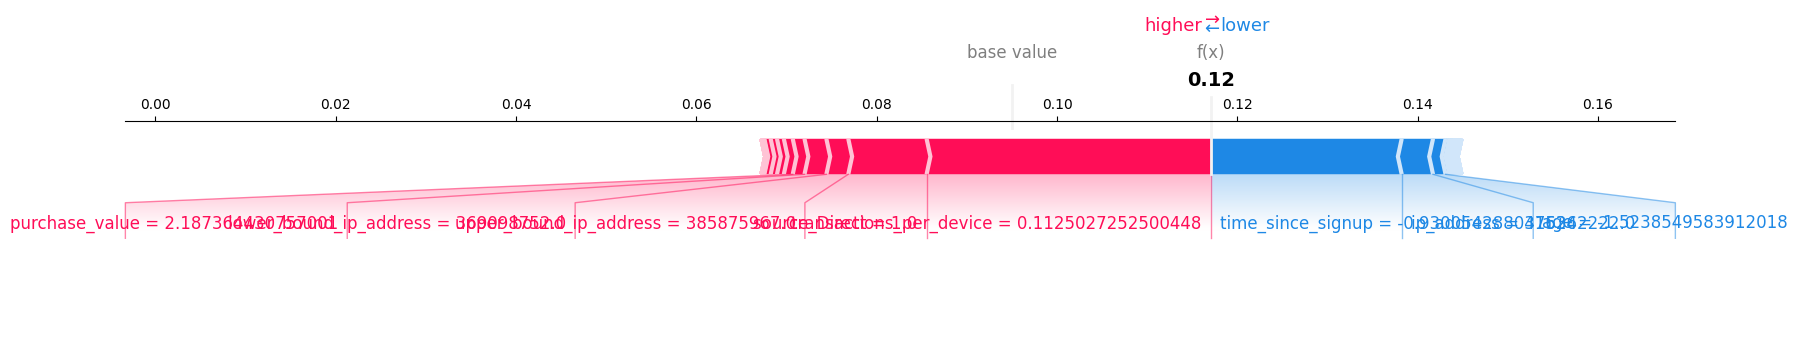

In [43]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[
        X_test.index.get_loc(fn_index),
        :,
        1
    ],
    X_test.loc[fn_index],
    matplotlib=True
)

In [44]:
y_pred_30 = (
    best_model.predict_proba(X_test)[:, 1] >= 0.30
).astype(int)

print(confusion_matrix(y_test, y_pred_30))

print(classification_report(
    y_test,
    y_pred_30
))

[[23300    76]
 [ 1111  1343]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.95      0.55      0.69      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.83     25830
weighted avg       0.95      0.95      0.95     25830



In [45]:
results30 = X_test.copy()

results30["actual"] = y_test
results30["predicted"] = y_pred_30

tp_index_30 = results30[
    (results30["actual"] == 1) &
    (results30["predicted"] == 1)
].index[0]

fp_index_30 = results30[
    (results30["actual"] == 0) &
    (results30["predicted"] == 1)
].index[0]

fn_index_30 = results30[
    (results30["actual"] == 1) &
    (results30["predicted"] == 0)
].index[0]

print("TP:", tp_index_30)
print("FP:", fp_index_30)
print("FN:", fn_index_30)

TP: 118326
FP: 72100
FN: 12320


In [19]:
feature_importance.head(5)

,Feature,Importance
4,time_since_signup,0.481588
8,transactions_per_device,0.432978
3,ip_address,0.009487
2,age,0.007293
1,purchase_value,0.007242


In [20]:
# Business Recommendations

1. Transactions occurring shortly after account creation should trigger additional verification.

2. Users exhibiting unusually high transaction frequency should receive increased fraud monitoring.

3. High-risk geographic regions identified through IP-country mapping should receive enhanced authentication checks.

4. Transactions occurring during unusual hours should be flagged for review.

5. Device reuse across multiple accounts should be monitored as a potential fraud indicator.

SyntaxError: invalid syntax (1162032798.py, line 3)